# Lesson 1.4 — The Continuity Equation

## The Traffic Jam Analogy

Imagine a single-lane highway. If cars enter a section faster than they leave, traffic
density (cars per km) increases — a jam forms. If they leave faster than they enter, the
section empties. The **continuity equation** says exactly this for a fluid:

$$\frac{\partial \rho}{\partial t} = - \frac{\partial (\rho u)}{\partial x}$$

*"The rate of density change = minus the spatial gradient of mass flux."*

---

## Derivation from First Principles

Consider a small 1D control volume of length $\Delta x$, cross-sectional area $A$.
The mass inside is $m = \rho A \Delta x$.

Mass entering at $x$ per unit time: $(\rho u A)|_x$  
Mass leaving at $x+\Delta x$ per unit time: $(\rho u A)|_{x+\Delta x}$

Conservation of mass:
$$\frac{d(\rho A \Delta x)}{dt} = (\rho u A)|_x - (\rho u A)|_{x+\Delta x}$$

Dividing by $A \Delta x$ and taking $\Delta x \to 0$:

$$\frac{\partial \rho}{\partial t} + \frac{\partial (\rho u)}{\partial x} = 0$$

In 3D, using vector notation:

$$\boxed{\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0}$$

---

## Incompressible Form

For liquids (water, oil) and low-speed gases (Mach $\ll$ 0.3), density is nearly constant:
$\rho \approx$ const. The continuity equation collapses to:

$$\nabla \cdot \mathbf{u} = 0$$

In 2D: $\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$

In 3D: $\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} + \frac{\partial w}{\partial z} = 0$

This is a **kinematic constraint** — it says nothing about forces. It just says:
for every fluid particle, what flows in must flow out. A divergence-free field is also called
**solenoidal**.

---

## The Streamfunction — A Built-In Continuity Enforcer

For 2D incompressible flow, there exists a **streamfunction** $\psi(x,y)$ such that:

$$u = \frac{\partial \psi}{\partial y}, \qquad v = -\frac{\partial \psi}{\partial x}$$

Any $\psi$ automatically satisfies $\nabla \cdot \mathbf{u} = 0$:

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = \frac{\partial^2 \psi}{\partial x \partial y} - \frac{\partial^2 \psi}{\partial y \partial x} = 0$$

Contours of $\psi$ are the **streamlines** you see in flow visualizations.


Poiseuille flow — max |div u| = 0.00e+00


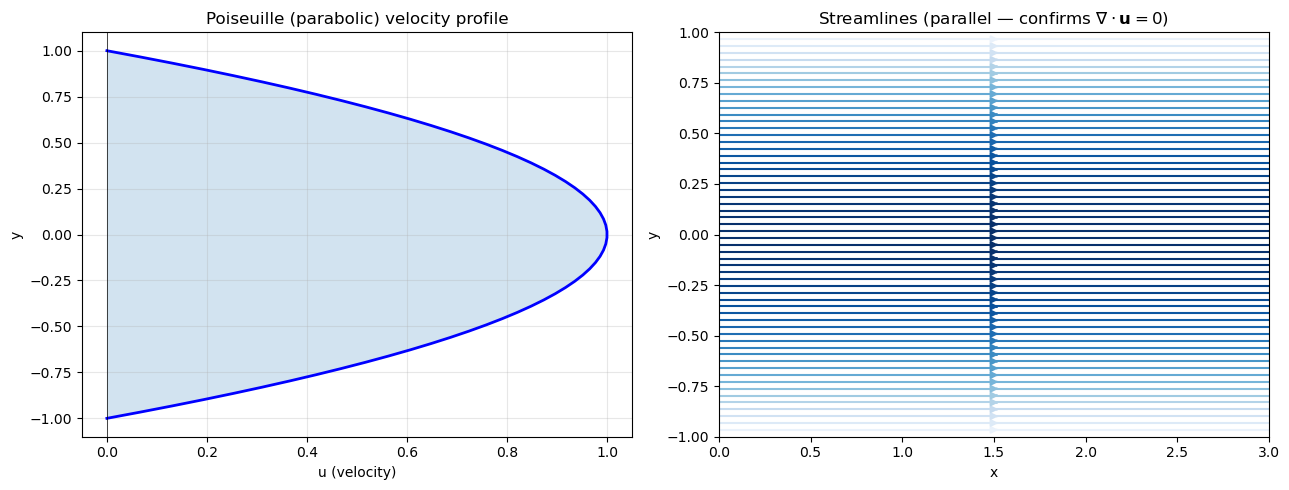

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Verify continuity for a channel flow (Poiseuille profile)
# u(y) = U_max * (1 - (y/H)^2), v = 0
# Exact: du/dx + dv/dy = 0 + 0 = 0 everywhere

N = 60
H = 1.0
x = np.linspace(0, 3, N)
y = np.linspace(-H, H, N)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)

U_max = 1.0
U = U_max * (1 - (Y/H)**2)   # parabolic profile, no x-variation
V = np.zeros_like(U)          # no v component

# Numerical divergence
dU_dx = np.gradient(U, dx, axis=1)
dV_dy = np.gradient(V, dy, axis=0)
div_u = dU_dx + dV_dy

print(f"Poiseuille flow — max |div u| = {np.max(np.abs(div_u)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Velocity profile at x=1.5
ix = N // 2
axes[0].plot(U[:, ix], y, 'b-', linewidth=2)
axes[0].fill_betweenx(y, 0, U[:, ix], alpha=0.2)
axes[0].set_xlabel('u (velocity)')
axes[0].set_ylabel('y')
axes[0].set_title('Poiseuille (parabolic) velocity profile')
axes[0].axvline(0, color='k', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Streamlines
axes[1].streamplot(X, Y, U, V, color=U, cmap='Blues', density=2)
axes[1].set_title('Streamlines (parallel — confirms $\\nabla\\cdot\\mathbf{u}=0$)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

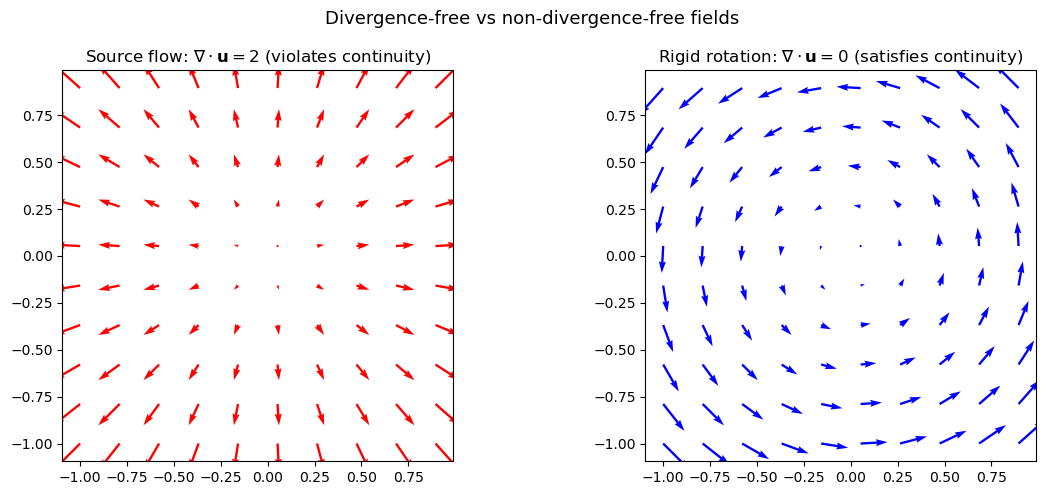

Source flow: fluid 'appears' from every point — physically impossible for incompressible fluid.
Rotation: every particle moves but nothing accumulates — this is physical.


In [2]:
# What does a NON-divergence-free field look like? (violates continuity)
# u = x, v = y → div u = 1 + 1 = 2 (source flow)

N = 20
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)

U_source = X.copy()   # radial source: u = x
V_source = Y.copy()   # radial source: v = y
div_source = 2 * np.ones_like(X)  # exact divergence = 2

U_inc = -Y.copy()    # incompressible rotation: u = -y
V_inc = X.copy()     # incompressible rotation: v = x
# div = -dY/dx + dX/dy = 0 + 0 = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

skip = 2
axes[0].quiver(X[::skip, ::skip], Y[::skip, ::skip],
               U_source[::skip, ::skip], V_source[::skip, ::skip], color='red')
axes[0].set_title('Source flow: $\\nabla\\cdot\\mathbf{u}=2$ (violates continuity)')
axes[0].set_aspect('equal')

axes[1].quiver(X[::skip, ::skip], Y[::skip, ::skip],
               U_inc[::skip, ::skip], V_inc[::skip, ::skip], color='blue')
axes[1].set_title('Rigid rotation: $\\nabla\\cdot\\mathbf{u}=0$ (satisfies continuity)')
axes[1].set_aspect('equal')

plt.suptitle('Divergence-free vs non-divergence-free fields', fontsize=13)
plt.tight_layout()
plt.show()

print("Source flow: fluid 'appears' from every point — physically impossible for incompressible fluid.")
print("Rotation: every particle moves but nothing accumulates — this is physical.")

## Key Takeaways

- The continuity equation is Newton's law applied to mass inside a control volume.
- For incompressible flow: $\nabla \cdot \mathbf{u} = 0$ — zero divergence everywhere.
- A **divergence-free** (solenoidal) field conserves mass automatically.
- The **streamfunction** $\psi$ guarantees $\nabla \cdot \mathbf{u} = 0$ by construction in 2D.
- In SIMPLE (Module 02), enforcing this constraint is the core challenge — it links pressure to velocity.

---

**Next**: Lesson 1.5 — Finite Difference Method: turning derivatives into algebra.
